### Name: Md. Nafiz Mahmud Shawon
### Mail: work.nafiz@gmail.com


# EDA


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression, SGDClassifier
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV


In [2]:
df = pd.read_csv('/content/adult_income.csv')
df.sample(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
41845,21,Private,229769,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Female,0,0,40,Mexico,<=50K.
36533,25,Private,139863,1st-4th,2,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,Mexico,<=50K.
44147,39,Private,97771,Assoc-voc,11,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,<=50K.
26249,66,Private,186324,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,0,5,United-States,>50K
27708,48,Private,278039,7th-8th,4,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,<=50K


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [4]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
# dropping fnlwgt or weight. cause etar sathe income er temon kono connection nei. hoyto indirectly kora jabe but not important.
df.drop(columns=['fnlwgt'], axis=1, inplace=True)
df.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'income'],
      dtype='object')

In [6]:
df.isnull().sum()

,0
age,0
workclass,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0
capital-gain,0


In [7]:
df.duplicated().sum()

np.int64(4487)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.shape

(44355, 14)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44355 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             44355 non-null  int64 
 1   workclass       44355 non-null  object
 2   education       44355 non-null  object
 3   education-num   44355 non-null  int64 
 4   marital-status  44355 non-null  object
 5   occupation      44355 non-null  object
 6   relationship    44355 non-null  object
 7   race            44355 non-null  object
 8   sex             44355 non-null  object
 9   capital-gain    44355 non-null  int64 
 10  capital-loss    44355 non-null  int64 
 11  hours-per-week  44355 non-null  int64 
 12  native-country  44355 non-null  object
 13  income          44355 non-null  object
dtypes: int64(5), object(9)
memory usage: 5.1+ MB


In [12]:
df.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,44355.000000,44355.000000,44355.000000,44355.000000,44355.000000
mean,39.242025,10.095096,1180.267501,95.881096,40.590553
std,13.755937,2.634697,7781.242634,420.914966,12.725503
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,38.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,13.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [13]:
df.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'income'],
      dtype='object')

In [14]:
obj_col = df.select_dtypes(include='object').columns
for col in obj_col:
    df[col] = df[col].str.strip()

In [15]:
df['income'] = df['income'].str.strip().replace({'<=50K.':'<=50K', '>50K.':'>50K'})


In [16]:
df['occupation'].unique()
# df['occupation'].value_counts()


array(['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners',
       'Prof-specialty', 'Other-service', 'Sales', 'Craft-repair',
       'Transport-moving', 'Farming-fishing', 'Machine-op-inspct',
       'Tech-support', '?', 'Protective-serv', 'Armed-Forces',
       'Priv-house-serv'], dtype=object)

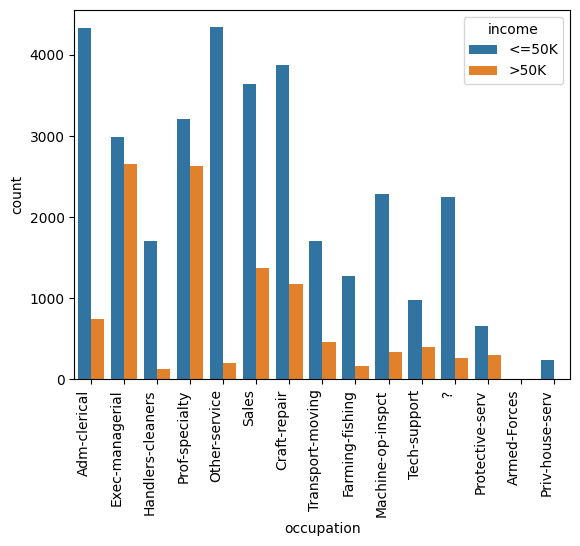

In [17]:
sns.countplot(data=df, x="occupation", hue="income")
plt.xticks(rotation=90, ha='right')
plt.show()

In [18]:
df['education-num'].unique()
# df['education-num'].value_counts()


array([13,  9,  7, 14,  5, 10, 12, 11,  4, 16, 15,  3,  6,  2,  1,  8])

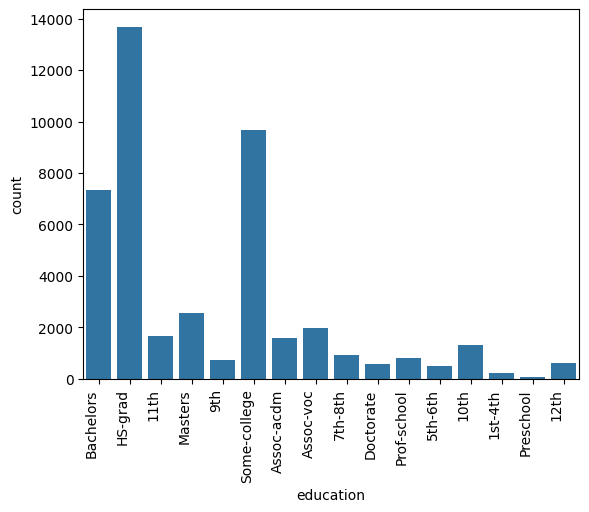

In [19]:
sns.countplot(data=df, x='education')
plt.xticks(rotation=90, ha='right')
plt.show()

In [20]:
df['hours-per-week'].unique()
# df['hours-per-week'].value_counts()



array([40, 13, 16, 45, 50, 80, 30, 35, 60, 20, 52, 44, 15, 25, 38, 43, 55,
       48, 58, 32, 70,  2, 22, 56, 41, 28, 36, 24, 46, 42, 12, 65,  1, 10,
       34, 75, 98, 33, 54,  8,  6, 64, 19, 18, 72,  5,  9, 47, 37, 21, 26,
       14,  4, 59,  7, 99, 53, 39, 62, 57, 78, 90, 66, 11, 49, 84,  3, 17,
       68, 27, 85, 31, 51, 77, 63, 23, 87, 88, 73, 89, 97, 94, 29, 96, 67,
       82, 86, 91, 81, 76, 92, 61, 74, 95, 79, 69])

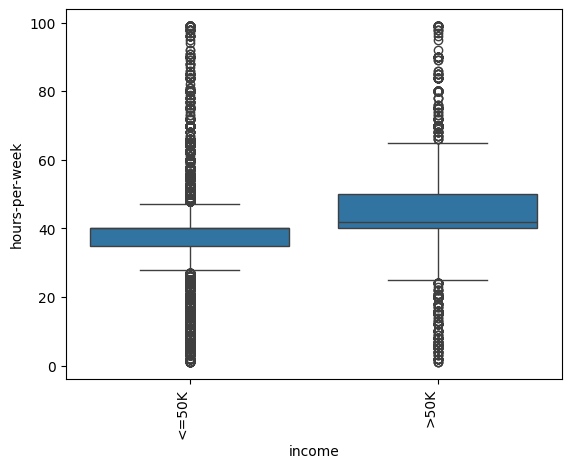

In [21]:
sns.boxplot(data=df, x='income', y='hours-per-week')
plt.xticks(rotation=90, ha='right')
plt.show()

In [22]:
df['income'].unique()
# df['income'].value_counts()


array(['<=50K', '>50K'], dtype=object)

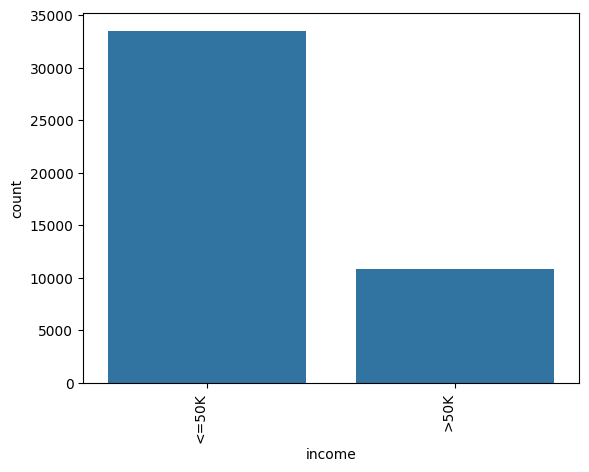

In [23]:
sns.countplot(data=df, x='income')
plt.xticks(rotation=90, ha='right')
plt.show()

### Documentation
1. Occupation
2. Education num
3. Hours per week

---

### Cause ei 3 ta feature amar mote income er upor sob theke besi effect rakhe. education er upor base kore valo job paoya jay jetar sallary tulonamulok besi thake. valo education mane valo ekta title er job. and hours besi hole per hour salary besi hole tokkhon setao exponentially bere jay. (jodio ekhane abar kom salary but hour besi ekta fact thekei jay jara low end er job kore tader khettre)

## Ranking my choosing features:
1. Education num
2. Occupation
3. Hours per week



*italicized text*# New Section

# Regression

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44355 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             44355 non-null  int64 
 1   workclass       44355 non-null  object
 2   education       44355 non-null  object
 3   education-num   44355 non-null  int64 
 4   marital-status  44355 non-null  object
 5   occupation      44355 non-null  object
 6   relationship    44355 non-null  object
 7   race            44355 non-null  object
 8   sex             44355 non-null  object
 9   capital-gain    44355 non-null  int64 
 10  capital-loss    44355 non-null  int64 
 11  hours-per-week  44355 non-null  int64 
 12  native-country  44355 non-null  object
 13  income          44355 non-null  object
dtypes: int64(5), object(9)
memory usage: 5.1+ MB


In [25]:
df.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,44355.000000,44355.000000,44355.000000,44355.000000,44355.000000
mean,39.242025,10.095096,1180.267501,95.881096,40.590553
std,13.755937,2.634697,7781.242634,420.914966,12.725503
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,38.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,13.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [26]:
df.isnull().sum()

,0
age,0
workclass,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0
capital-gain,0


In [27]:
df.duplicated().sum()


np.int64(1887)

In [28]:
df.drop_duplicates(inplace=True)

In [29]:
df.duplicated().sum()


np.int64(0)

In [30]:
df[['capital-gain', 'capital-loss']].describe()

,capital-gain,capital-loss
count,42468.000000,42468.000000
mean,1226.217128,99.859212
std,7931.500736,429.072095
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,99999.000000,4356.000000


In [31]:
df.drop('education', axis=1, inplace=True)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42468 entries, 0 to 48841
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             42468 non-null  int64 
 1   workclass       42468 non-null  object
 2   education-num   42468 non-null  int64 
 3   marital-status  42468 non-null  object
 4   occupation      42468 non-null  object
 5   relationship    42468 non-null  object
 6   race            42468 non-null  object
 7   sex             42468 non-null  object
 8   capital-gain    42468 non-null  int64 
 9   capital-loss    42468 non-null  int64 
 10  hours-per-week  42468 non-null  int64 
 11  native-country  42468 non-null  object
 12  income          42468 non-null  object
dtypes: int64(5), object(8)
memory usage: 4.5+ MB


In [33]:
df.columns

Index(['age', 'workclass', 'education-num', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
       'hours-per-week', 'native-country', 'income'],
      dtype='object')

In [34]:
df.shape

(42468, 13)

In [35]:
df.sample(5)

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
27504,51,Local-gov,10,Married-civ-spouse,Adm-clerical,Wife,White,Female,0,0,40,United-States,<=50K
21388,24,Private,1,Never-married,Machine-op-inspct,Own-child,White,Female,0,0,30,United-States,<=50K
18152,49,Federal-gov,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,<=50K
10895,22,State-gov,13,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,40,United-States,<=50K
10487,27,Private,9,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,1848,45,United-States,>50K


In [36]:
df.isna().sum()

,0
age,0
workclass,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0
capital-gain,0
capital-loss,0


In [37]:
df.isnull().sum()

,0
age,0
workclass,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0
capital-gain,0
capital-loss,0


In [38]:
df.value_counts().sum()

np.int64(42468)

In [39]:
df.columns

Index(['age', 'workclass', 'education-num', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
       'hours-per-week', 'native-country', 'income'],
      dtype='object')

In [40]:
df.shape

(42468, 13)

In [41]:
df.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,42468.000000,42468.000000,42468.000000,42468.000000,42468.000000
mean,39.476947,10.094801,1226.217128,99.859212,40.650702
std,13.779595,2.658658,7931.500736,429.072095,12.867960
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,29.000000,9.000000,0.000000,0.000000,38.000000
50%,38.000000,10.000000,0.000000,0.000000,40.000000
75%,49.000000,13.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42468 entries, 0 to 48841
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             42468 non-null  int64 
 1   workclass       42468 non-null  object
 2   education-num   42468 non-null  int64 
 3   marital-status  42468 non-null  object
 4   occupation      42468 non-null  object
 5   relationship    42468 non-null  object
 6   race            42468 non-null  object
 7   sex             42468 non-null  object
 8   capital-gain    42468 non-null  int64 
 9   capital-loss    42468 non-null  int64 
 10  hours-per-week  42468 non-null  int64 
 11  native-country  42468 non-null  object
 12  income          42468 non-null  object
dtypes: int64(5), object(8)
memory usage: 4.5+ MB


In [43]:
df.sample(10)

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
14591,43,Private,10,Married-civ-spouse,Prof-specialty,Wife,Other,Female,0,0,6,Puerto-Rico,<=50K
3153,56,Federal-gov,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,>50K
43632,28,State-gov,14,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,50,United-States,<=50K
43052,42,State-gov,11,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
12659,49,Self-emp-inc,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States,>50K
7414,19,Private,10,Never-married,Sales,Not-in-family,White,Female,0,0,40,United-States,<=50K
20352,37,Self-emp-not-inc,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
38367,43,Private,9,Never-married,Machine-op-inspct,Unmarried,Black,Female,0,0,40,United-States,<=50K
48827,55,Private,9,Separated,Priv-house-serv,Not-in-family,White,Female,0,0,32,United-States,<=50K
47216,47,Private,2,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,40,United-States,<=50K


### Here,
1. No missing values
2. No duplicates


### train text split part

In [44]:
x = df.drop('hours-per-week', axis=1)
y = df['hours-per-week']


In [45]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.02, random_state=42)

In [46]:
x_train.isnull().sum()

,0
age,0
workclass,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0
capital-gain,0
capital-loss,0


In [47]:
y_train.isnull().sum()

np.int64(0)

In [48]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41618 entries, 16527 to 16965
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             41618 non-null  int64 
 1   workclass       41618 non-null  object
 2   education-num   41618 non-null  int64 
 3   marital-status  41618 non-null  object
 4   occupation      41618 non-null  object
 5   relationship    41618 non-null  object
 6   race            41618 non-null  object
 7   sex             41618 non-null  object
 8   capital-gain    41618 non-null  int64 
 9   capital-loss    41618 non-null  int64 
 10  native-country  41618 non-null  object
 11  income          41618 non-null  object
dtypes: int64(4), object(8)
memory usage: 4.1+ MB


In [49]:
x_train.describe()

,age,education-num,capital-gain,capital-loss
count,41618.000000,41618.000000,41618.000000,41618.000000
mean,39.475756,10.094214,1227.667379,99.949493
std,13.785095,2.655544,7941.927543,429.253329
min,17.000000,1.000000,0.000000,0.000000
25%,29.000000,9.000000,0.000000,0.000000
50%,38.000000,10.000000,0.000000,0.000000
75%,49.000000,13.000000,0.000000,0.000000
max,90.000000,16.000000,99999.000000,4356.000000


### numerical outliers and skewed or not checking

In [50]:
# numerical

# sns.kdeplot(data=x_train, x='age')
# sns.boxplot(data=x_train, y='age')

# sns.kdeplot(data=x_train, x='education-num')
# sns.boxplot(data=x_train, y='education-num')

# sns.kdeplot(data=x_train, x='capital-gain')
# sns.boxplot(data=x_train, y='capital-gain')

# sns.kdeplot(data=x_train, x='capital-loss')
# sns.boxplot(data=x_train, y='capital-loss')

# plt.xticks(rotation=90)
# plt.show()

In [51]:
numerical_list=['age', 'education-num', 'capital-gain', 'capital-loss']
categorical_list=['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']

In [52]:
numerical_imputer = SimpleImputer(strategy="median")
categorical_imputer = SimpleImputer(strategy='most_frequent')

In [53]:
numerical_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('scaler', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessing = ColumnTransformer(
    transformers=[
        ('numerical', numerical_pipeline, numerical_list),
        ('categorical', categorical_pipeline, categorical_list)
    ]
)


### Documentation
Numerical feature er missing value fill korte Median use korechi, karon eta outlier er effect kom ney. Categorical feature er jonno Most Frequent use korechi. Text feature gula ke numeric bananor jonno OneHotEncoder use korechi. Numerical feature gulor scale same korar jonno StandardScaler apply korechi. Sob preprocessing ColumnTransformer diye ekshathe combine korechi.

# Regression Modeling & Evaluation

### linear regression

In [54]:
lr_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessing),
        ('lr_model', LinearRegression())
    ]
)

lr_pipeline.fit(x_train, y_train)
lr_y_pred = lr_pipeline.predict(x_test)

r2_lr = r2_score(y_test, lr_y_pred)
mae_lr = mean_absolute_error(y_test, lr_y_pred)
mse_lr = mean_squared_error(y_test, lr_y_pred)

print(f"""
using lr:
R2: {r2_lr}
Mae: {mae_lr}
Mse: {mse_lr}
""")


using lr:
R2: 0.17583460795119443
Mae: 8.549090546227387
Mse: 160.02549752776807



### SGD regression

In [55]:
sgd_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessing),
        ('lr_model', SGDClassifier(random_state=42))
    ]
)

sgd_pipeline.fit(x_train, y_train)
lr_y_pred = sgd_pipeline.predict(x_test)

r2_sgd = r2_score(y_test, lr_y_pred)
mae_sgd = mean_absolute_error(y_test, lr_y_pred)
mse_sgd = mean_squared_error(y_test, lr_y_pred)

print(f"""
using sgd:
R2: {r2_sgd}
Mae: {mae_sgd}
Mse: {mse_sgd}
""")


using sgd:
R2: -0.06962652387762414
Mae: 8.944705882352942
Mse: 207.68588235294118



In [56]:
comparison_df = pd.DataFrame({
    'metric':['R2', 'Mae', 'Mse'],
    'Linear regressionn':[r2_lr, mae_lr, mse_lr],
    'SGD regression': [r2_sgd, mae_sgd, mse_sgd]
  }
)
comparison_df

,metric,Linear regressionn,SGD regression
0,R2,0.175835,-0.069627
1,Mae,8.549091,8.944706
2,Mse,160.025498,207.685882


## conclusion
### from this chart we can say that linear regression is better than sgd regression.

Linear Regression better perform koreche, karon eta higher R2 ebong lower mae, mse score peyese. Tai ei dataset er jonno eta beshi accurate model.

# Classification pipeline and error analysis

In [57]:
new_df = pd.read_csv('/content/adult_income.csv')
new_df.shape

(48842, 15)

In [58]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [59]:
new_df.drop('education', axis=1, inplace=True)

In [60]:
new_df.drop(columns=['fnlwgt'], axis=1, inplace=True)


In [61]:
obj_col = new_df.select_dtypes(include='object').columns
for col in obj_col:
    new_df[col] = new_df[col].str.strip()

In [62]:
new_df['income'] = new_df['income'].str.strip().replace({'<=50K.':'<=50K', '>50K.':'>50K'})

In [63]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   education-num   48842 non-null  int64 
 3   marital-status  48842 non-null  object
 4   occupation      48842 non-null  object
 5   relationship    48842 non-null  object
 6   race            48842 non-null  object
 7   sex             48842 non-null  object
 8   capital-gain    48842 non-null  int64 
 9   capital-loss    48842 non-null  int64 
 10  hours-per-week  48842 non-null  int64 
 11  native-country  48842 non-null  object
 12  income          48842 non-null  object
dtypes: int64(5), object(8)
memory usage: 4.8+ MB


In [64]:
new_df.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,10.078089,1079.067626,87.502314,40.422382
std,13.710510,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [65]:
new_df.isnull().sum()

,0
age,0
workclass,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0
capital-gain,0
capital-loss,0


In [66]:
new_df.drop_duplicates(inplace=True)

In [67]:
new_df.duplicated().sum()

np.int64(0)

In [68]:
label_encoder_income = LabelEncoder()
new_df['income'] = label_encoder_income.fit_transform(new_df['income'])

In [69]:
x = new_df.drop('income', axis=1)
y = new_df['income']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [70]:
numerical=['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

categorical=['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

In [71]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42468 entries, 0 to 48841
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             42468 non-null  int64 
 1   workclass       42468 non-null  object
 2   education-num   42468 non-null  int64 
 3   marital-status  42468 non-null  object
 4   occupation      42468 non-null  object
 5   relationship    42468 non-null  object
 6   race            42468 non-null  object
 7   sex             42468 non-null  object
 8   capital-gain    42468 non-null  int64 
 9   capital-loss    42468 non-null  int64 
 10  hours-per-week  42468 non-null  int64 
 11  native-country  42468 non-null  object
dtypes: int64(5), object(7)
memory usage: 4.2+ MB


In [72]:
y.info()

<class 'pandas.core.series.Series'>
Index: 42468 entries, 0 to 48841
Series name: income
Non-Null Count  Dtype
--------------  -----
42468 non-null  int64
dtypes: int64(1)
memory usage: 663.6 KB


In [73]:
numerical_imputer = SimpleImputer(strategy="median")
categorical_imputer = SimpleImputer(strategy='most_frequent')

In [74]:
numerical_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('scaler', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessing = ColumnTransformer(
    transformers=[
        ('numerical', numerical_pipeline, numerical),
        ('categorical', categorical_pipeline, categorical)
    ]
)


In [75]:
x_train.columns

Index(['age', 'workclass', 'education-num', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
       'hours-per-week', 'native-country'],
      dtype='object')

In [76]:
logistic_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessing),
        ('classifier', LogisticRegression(max_iter=1000))
    ]
)

logistic_pipeline.fit(x_train, y_train)
y_pred = logistic_pipeline.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.8418883918059807
Precision: 0.7170249854735619
Recall: 0.5904306220095694


In [77]:
comparison_df_new = pd.DataFrame({
    'metric':['Accuracy', 'Precision', 'Recall'],
    'Logistic regressionn':[accuracy, precision, recall],
  }
)
comparison_df_new

,metric,Logistic regressionn
0,Accuracy,0.841888
1,Precision,0.717025
2,Recall,0.590431


# Hyperparameter Tuning & Model Comparison

In [78]:
knn_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessing),
        ('classifier', KNeighborsClassifier()),
    ]
)


In [ ]:
grid = {
    "classifier__n_neighbors": range(1,30),
    "classifier__weights": ['uniform', 'distance'],
    "classifier__metric": ["euclidean", "manhattan", "minkowski"]
}

grid_search = GridSearchCV(
    estimator= knn_pipeline,
    param_grid=grid,
    cv=5
)

grid_search.fit(x_train, y_train)

In [ ]:
grid_search.best_params_